In [1]:
from datasets import load_dataset
import pandas as pd

dataset=load_dataset("SetFit/ag_news")
print(dataset)

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label', 'label_text'],
        num_rows: 7600
    })
})


In [2]:
for i in range(5):
    print(dataset["train"][i]["text"],"\n")
    print(dataset["train"][i]["label"],"\n")
    print(dataset["train"][i]["label_text"],"\n")
    print("=="*60)

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again. 

2 

Business 

Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market. 

2 

Business 

Oil and Economy Cloud Stocks' Outlook (Reuters) Reuters - Soaring crude prices plus worries\about the economy and the outlook for earnings are expected to\hang over the stock market next week during the depth of the\summer doldrums. 

2 

Business 

Iraq Halts Oil Exports from Main Southern Pipeline (Reuters) Reuters - Authorities have halted oil export\flows from the main pipeline in southern Iraq after\intelligence showed a rebel militia could strike\infrastructure, an oil official said on Saturday. 

2 

Business 

Oil prices soar to all-time re

In [3]:
df_train=pd.DataFrame(dataset["train"])
df_train.to_csv('./data/raw/df_train.csv',index=False)

display(df_train)

,text,label,label_text
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,2,Business
4,"Oil prices soar to all-time record, posing new...",2,Business
...,...,...,...
119995,Pakistan's Musharraf Says Won't Quit as Army C...,0,World
119996,Renteria signing a top-shelf deal Red Sox gene...,1,Sports
119997,Saban not going to Dolphins yet The Miami Dolp...,1,Sports
119998,Today's NFL games PITTSBURGH at NY GIANTS Time...,1,Sports


In [5]:
df_test=pd.DataFrame(dataset["test"])
df_test.to_csv('./data/raw/df_test.csv',index=False)
display(df_test)

,text,label,label_text
0,Fears for T N pension after talks Unions repre...,2,Business
1,The Race is On: Second Private Team Sets Launc...,3,Sci/Tech
2,Ky. Company Wins Grant to Study Peptides (AP) ...,3,Sci/Tech
3,Prediction Unit Helps Forecast Wildfires (AP) ...,3,Sci/Tech
4,Calif. Aims to Limit Farm-Related Smog (AP) AP...,3,Sci/Tech
...,...,...,...
7595,Around the world Ukrainian presidential candid...,0,World
7596,Void is filled with Clement With the supply of...,1,Sports
7597,Martinez leaves bitter Like Roger Clemens did ...,1,Sports
7598,5 of arthritis patients in Singapore take Bext...,2,Business


In [5]:
print("display train DataFrame columns")
display(df_train.columns)
print("display  test  DataFrame columns")
display(df_test.columns)

display train DataFrame columns


Index(['text', 'label', 'label_text'], dtype='object')

display  test  DataFrame columns


Index(['text', 'label', 'label_text'], dtype='object')

In [6]:
print("display train DataFrame shapes")
display(df_train.shape)

print("display  test  DataFrame shapes")

display(df_test.shape)


display train DataFrame shapes


(120000, 3)

display  test  DataFrame shapes


(7600, 3)

In [7]:
print("\n display train DataFrame infos \n ")

df_train.info()

print("\n display  test  DataFrame onfos \n")

df_test.info()


 display train DataFrame infos 
 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   text        120000 non-null  object
 1   label       120000 non-null  int64 
 2   label_text  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB

 display  test  DataFrame onfos 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   text        7600 non-null   object
 1   label       7600 non-null   int64 
 2   label_text  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB


In [8]:
print("Display train DataFrame null values")
print(df_train.isna().sum(),"\n")
print("Display  test  DataFrame null values ")

print(df_test.isna().sum())

Display train DataFrame null values
text          0
label         0
label_text    0
dtype: int64 

Display  test  DataFrame null values 
text          0
label         0
label_text    0
dtype: int64


Duplicated values in the train DataFrame:
0 

Duplicated values in the test DataFrame:
0


In [10]:
print("Unique values in the train label column:")
print(df_train["label"].unique(), "\n")

print("Unique values in the test label column:")
print(df_test["label"].unique())


Unique values in the train label column:
[2 3 1 0] 

Unique values in the test label column:
[2 3 1 0]


In [11]:
print("Label distribution in the train set:")
print(df_train["label"].value_counts(), "\n")

print("Label distribution in the test set:")
print(df_test["label"].value_counts())

Label distribution in the train set:
label
2    30000
3    30000
1    30000
0    30000
Name: count, dtype: int64 

Label distribution in the test set:
label
2    1900
3    1900
1    1900
0    1900
Name: count, dtype: int64


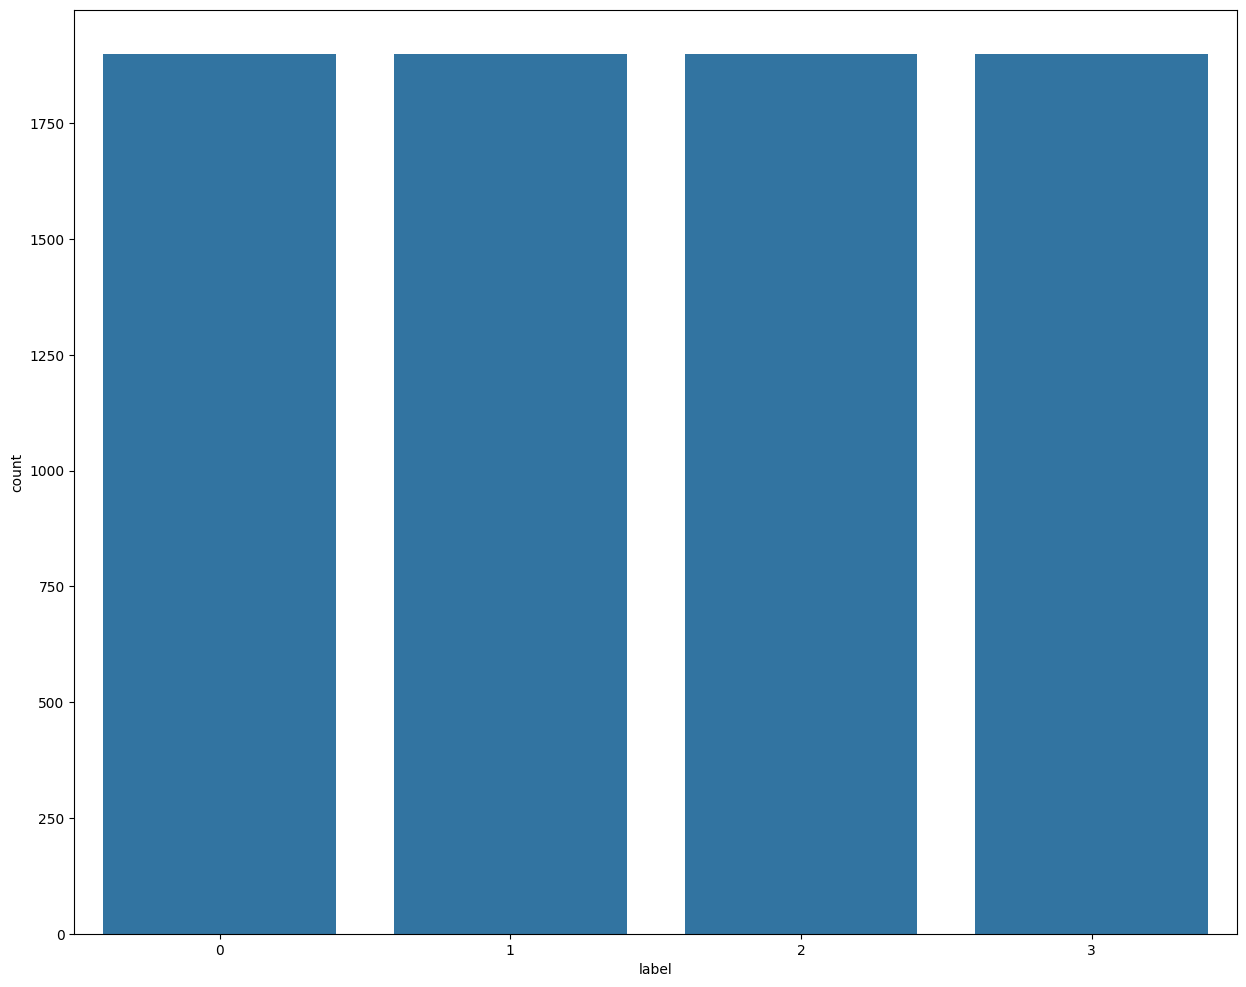

In [12]:
import seaborn as sns 
import matplotlib.pyplot as plt
plt.figure(figsize=(15,12))
sns.countplot(data=df_test,x="label")
plt.show()

In [13]:

print("describtion of text_length column")
df_train["text_length"]=df_train["text"].apply(lambda x : len(x.split()))
print(df_train["text_length"].describe())

print("describtion of text_length column")
df_test["text_length"]=df_test["text"].apply(lambda x : len(x.split()))
print(df_test["text_length"].describe())

describtion of text_length column
count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: text_length, dtype: float64
describtion of text_length column
count    7600.000000
mean       37.722368
std        10.129860
min        11.000000
25%        32.000000
50%        37.000000
75%        43.000000
max       137.000000
Name: text_length, dtype: float64


In [16]:
print(df_train["label_text"].unique())
print(df_train.columns)

['Business' 'Sci/Tech' 'Sports' 'World']
Index(['text', 'label', 'label_text', 'text_length'], dtype='object')


In [24]:
print(df_train["label_text"].value_counts())


label_text
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64


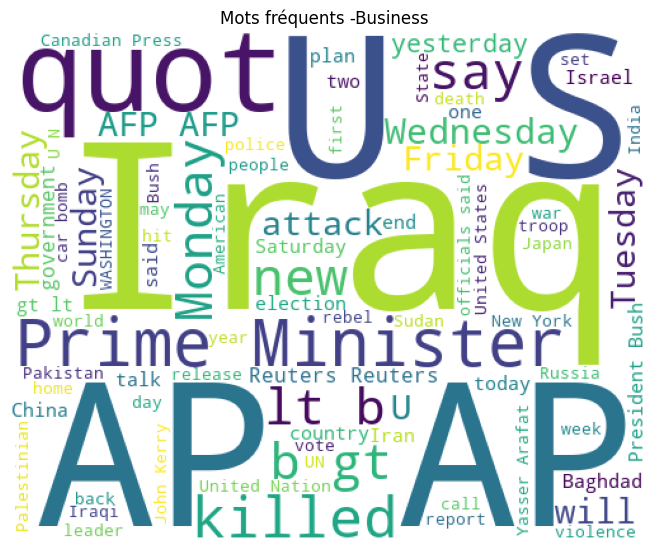

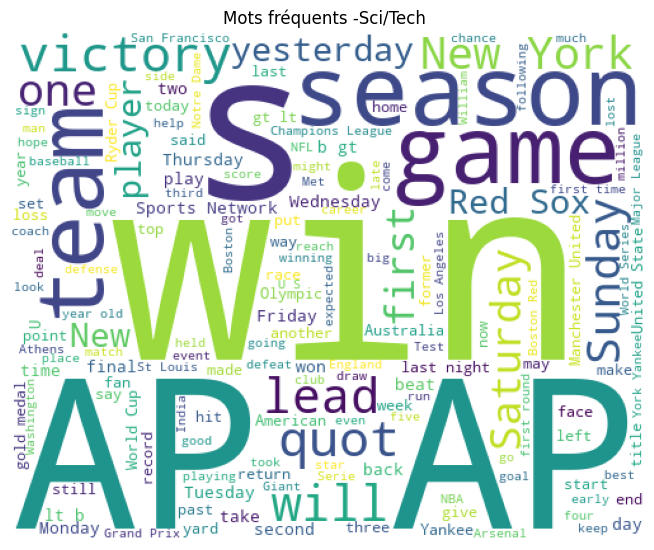

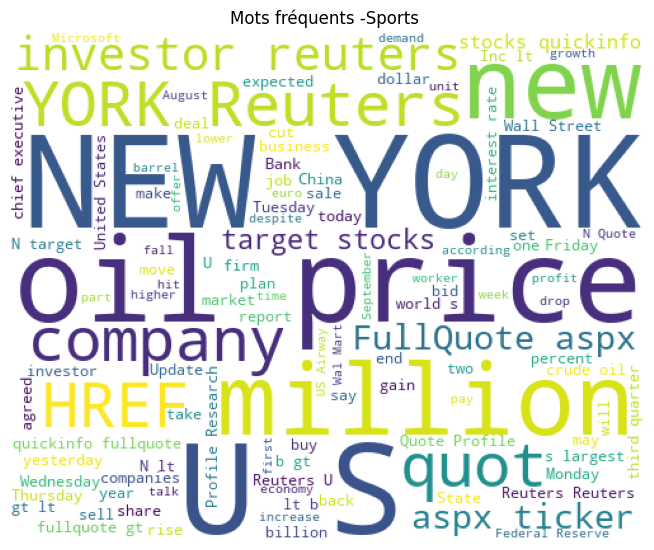

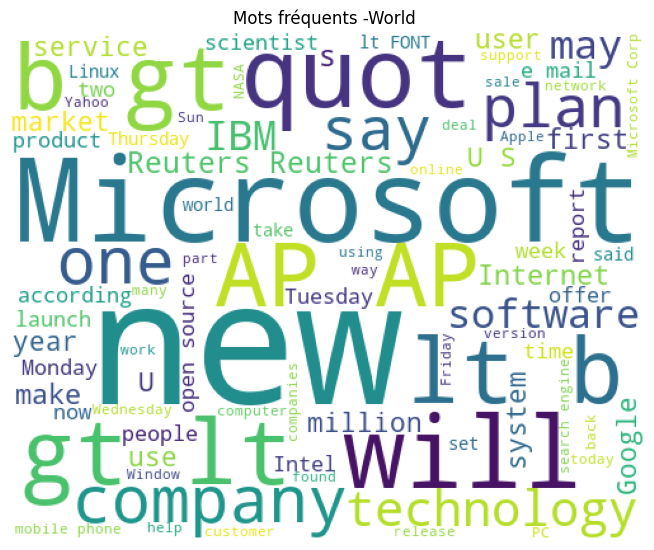

In [39]:
from wordcloud import WordCloud
wc=WordCloud(width=500 ,height=400,min_font_size=10,background_color="white")
labels=['Business', 'Sci/Tech' ,'Sports', 'World']

for i , label in enumerate(labels):
    wc_label=wc.generate(df_train[df_train["label"]==i]["text"].str.cat(sep=""))
    plt.figure(figsize=(18,12))
    plt.subplot(1,2,1)
    plt.imshow(wc_label)
    plt.title(f"Mots fréquents -{label} ")
    plt.axis('off')